In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [3]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Remove rows where Description is missing
df = df.dropna(subset=["Description"])

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [11]:
df = df[~df["InvoiceNo"].str.startswith("C")]

TypeError: bad operand type for unary ~: 'float'

In [12]:
df["InvoiceNo"].dtype

dtype('O')

In [13]:
df["InvoiceNo"].head(10)

0    536365
1    536365
2    536365
3    536365
4    536365
5    536365
6    536365
7    536366
8    536366
9    536367
Name: InvoiceNo, dtype: object

In [14]:
df["InvoiceNo"].str.startswith("C")

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
541904    NaN
541905    NaN
541906    NaN
541907    NaN
541908    NaN
Name: InvoiceNo, Length: 540455, dtype: object

In [15]:
df = df[~df["InvoiceNo"].str.startswith("C", na=False)]

In [16]:
df["InvoiceNo"].str.startswith("C")


0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
541904    NaN
541905    NaN
541906    NaN
541907    NaN
541908    NaN
Name: InvoiceNo, Length: 531167, dtype: object

In [17]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

In [18]:
df["InvoiceNo"].str.startswith("C")

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: InvoiceNo, Length: 531167, dtype: bool

In [ ]:
df["InvoiceNo"].dtype

dtype('O')

In [19]:
df = df[~df["InvoiceNo"].str.startswith("C")]

In [20]:
df.shape

(531167, 8)

In [21]:
df = df[df["Quantity"] > 0]

In [22]:
df.shape

(530693, 8)

In [23]:
top_products = df["Description"].value_counts().head(10)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    2327
JUMBO BAG RED RETROSPOT               2115
REGENCY CAKESTAND 3 TIER              2019
PARTY BUNTING                         1707
LUNCH BAG RED RETROSPOT               1594
ASSORTED COLOUR BIRD ORNAMENT         1489
SET OF 3 CAKE TINS PANTRY DESIGN      1399
PACK OF 72 RETROSPOT CAKE CASES       1370
LUNCH BAG  BLACK SKULL.               1328
NATURAL SLATE HEART CHALKBOARD        1263
Name: count, dtype: int64

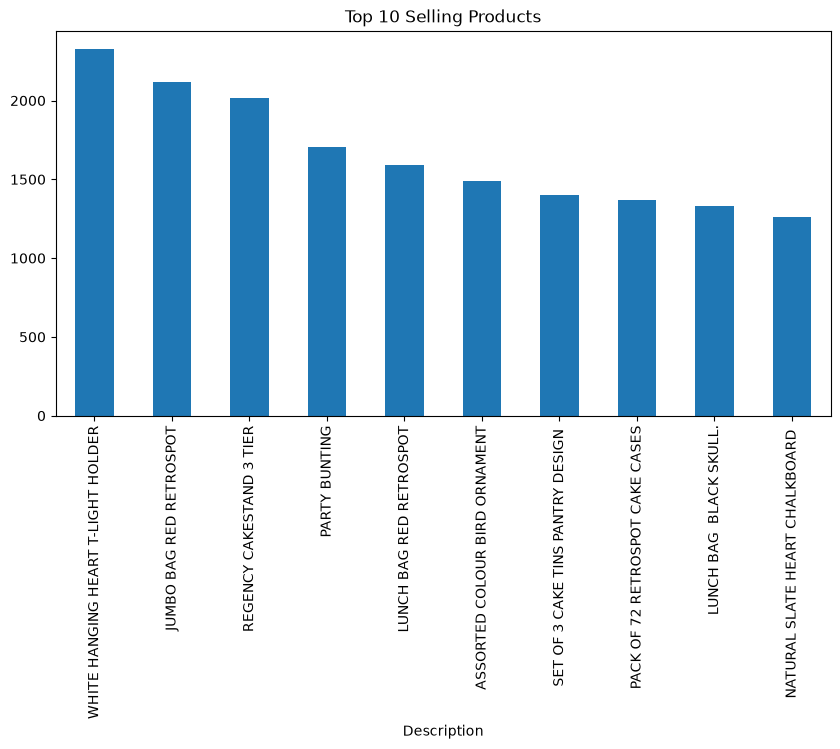

In [24]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Selling Products")
plt.show()

In [25]:
basket = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"]
      .sum()
      .unstack()
      .fillna(0)
)

In [26]:
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [28]:
basket = (basket > 0).astype(int)

In [29]:
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
basket.loc["536365"]

Description
 4 PURPLE FLOCK DINNER CANDLES    0
 50'S CHRISTMAS GIFT BAG LARGE    0
 DOLLY GIRL BEAKER                0
 I LOVE LONDON MINI BACKPACK      0
 I LOVE LONDON MINI RUCKSACK      0
                                 ..
wrongly coded 20713               0
wrongly coded 23343               0
wrongly marked                    0
wrongly marked 23343              0
wrongly sold (22719) barcode      0
Name: 536365, Length: 4077, dtype: int64

In [31]:
df[df["InvoiceNo"] == "536365"][["InvoiceNo","Description","Quantity"]]

,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6
5,536365,SET 7 BABUSHKA NESTING BOXES,2
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6


In [32]:
basket.loc["536365", "WHITE HANGING HEART T-LIGHT HOLDER"]

np.int64(1)

In [33]:
basket.loc["536365", "WHITE METAL LANTERN"]

np.int64(1)

In [34]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

c:\Users\MyPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [35]:
frequent_itemsets.head()

,support,itemsets
0,0.023242,frozenset({3 STRIPEY MICE FELTCRAFT})
1,0.024037,frozenset({4 TRADITIONAL SPINNING TOPS})
2,0.047427,frozenset({6 RIBBONS RUSTIC CHARM})
3,0.021702,frozenset({60 CAKE CASES DOLLY GIRL DESIGN})
4,0.030691,frozenset({60 CAKE CASES VINTAGE CHRISTMAS})


In [36]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

In [37]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.041120,0.065554,0.022497,0.547101,8.345784,1.0,0.019801,2.063256,0.917924,0.267257,0.515329,0.445142
1,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),frozenset({60 TEATIME FAIRY CAKE CASES}),0.065554,0.041120,0.022497,0.343182,8.345784,1.0,0.019801,1.459886,0.941926,0.267257,0.315015,0.445142
2,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.048669,0.038886,0.020759,0.426531,10.968864,1.0,0.018866,1.675965,0.955328,0.310781,0.403329,0.480187
3,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.038886,0.048669,0.020759,0.533844,10.968864,1.0,0.018866,2.040800,0.945603,0.310781,0.509996,0.480187
4,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.048669,0.052195,0.031784,0.653061,12.511932,1.0,0.029244,2.731908,0.967146,0.460101,0.633956,0.631003


In [38]:
rules = rules.sort_values(by="lift", ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
160,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.038141,0.038041,0.026917,0.705729,18.551648,1.0,0.025466,3.268957,0.983612,0.546371,0.694092,0.706650
161,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.038041,0.038141,0.026917,0.707572,18.551648,1.0,0.025466,3.289215,0.983510,0.546371,0.695976,0.706650
162,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.050407,0.029748,0.026917,0.533990,17.950627,1.0,0.025417,2.082042,0.994417,0.505597,0.519702,0.719416
159,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.029748,0.050407,0.026917,0.904841,17.950627,1.0,0.025417,9.979054,0.973243,0.505597,0.899790,0.719416
24,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.038041,0.050407,0.031436,0.826371,16.393893,1.0,0.029519,5.469083,0.976135,0.551394,0.817154,0.725008
25,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.050407,0.038041,0.031436,0.623645,16.393893,1.0,0.029519,2.555990,0.988847,0.551394,0.608762,0.725008
158,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.031436,0.052940,0.026917,0.856240,16.173782,1.0,0.025253,6.587791,0.968621,0.468453,0.848204,0.682341
163,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.052940,0.031436,0.026917,0.508443,16.173782,1.0,0.025253,1.970399,0.990615,0.468453,0.492489,0.682341
22,frozenset({GARDENERS KNEELING PAD KEEP CALM }),frozenset({GARDENERS KNEELING PAD CUP OF TEA }),0.045342,0.037644,0.027116,0.598028,15.886413,1.0,0.025409,2.394090,0.981559,0.485333,0.582305,0.659173
23,frozenset({GARDENERS KNEELING PAD CUP OF TEA }),frozenset({GARDENERS KNEELING PAD KEEP CALM }),0.037644,0.045342,0.027116,0.720317,15.886413,1.0,0.025409,3.413354,0.973707,0.485333,0.707033,0.659173


In [39]:
rules = rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

rules.head(10)

,antecedents,consequents,support,confidence,lift
160,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.026917,0.705729,18.551648
161,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.026917,0.707572,18.551648
162,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.026917,0.533990,17.950627
159,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.026917,0.904841,17.950627
24,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031436,0.826371,16.393893
25,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031436,0.623645,16.393893
158,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.026917,0.856240,16.173782
163,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.026917,0.508443,16.173782
22,frozenset({GARDENERS KNEELING PAD KEEP CALM }),frozenset({GARDENERS KNEELING PAD CUP OF TEA }),0.027116,0.598028,15.886413
23,frozenset({GARDENERS KNEELING PAD CUP OF TEA }),frozenset({GARDENERS KNEELING PAD KEEP CALM }),0.027116,0.720317,15.886413


In [40]:
def recommend(product):
    product = product.upper()

    recommendations = rules[
        rules["antecedents"].apply(
            lambda x: product in [item.upper() for item in x]
        )
    ]

    return recommendations[
        ["consequents", "confidence", "lift"]
    ].sort_values(
        by="lift",
        ascending=False
    )

In [41]:
recommend("WHITE METAL LANTERN")

,consequents,confidence,lift


In [42]:
recommend("HAND WARMER UNION JACK")

,consequents,confidence,lift


In [43]:
rules.shape

(176, 5)

In [44]:
frequent_itemsets.shape

(375, 2)

In [45]:
frequent_itemsets = apriori(
    basket,
    min_support=0.005,
    use_colnames=True
)

c:\Users\MyPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


MemoryError: Unable to allocate 356. GiB for an array with shape (1188111, 2, 20136) and data type int64

In [46]:
df = df[df["Country"] == "United Kingdom"]

In [47]:
df = df[
    ~df["Description"].str.lower().str.contains(
        "test|returned|wrong|adjust|amazon|manual|damaged|sample",
        na=False
    )
]

In [48]:
basket = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"]
      .sum()
      .unstack()
      .fillna(0)
)

In [49]:
basket = (basket > 0).astype(bool)

In [50]:
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,found box,had been put aside,incorrectly credited C550456 see 47,mailout,mailout,michel oops,on cargo order,rcvd be air temp fix for dotcom sit,to push order througha s stock was,website fixed
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

In [52]:
frequent_itemsets.head()

,support,itemsets
0,0.020074,frozenset({3 HOOK PHOTO SHELF ANTIQUE WHITE})
1,0.024166,frozenset({3 STRIPEY MICE FELTCRAFT})
2,0.021788,frozenset({4 TRADITIONAL SPINNING TOPS})
3,0.047282,frozenset({6 RIBBONS RUSTIC CHARM})
4,0.020517,frozenset({60 CAKE CASES DOLLY GIRL DESIGN})


In [53]:
frequent_itemsets.shape

(396, 2)

In [54]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)


In [55]:
rules = rules.sort_values(
    by="lift",
    ascending=False
)

In [56]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

In [ ]:
def recommend(product):
    product = product.upper()

    recommendations = rules[
        rules["antecedents"].apply(
            lambda x: any(product == item.upper() for item in x)
        )
    ]

    if recommendations.empty:
        print("No recommendations found.")
        return

    return recommendations[
        ["consequents", "confidence", "lift"]
    ].sort_values(
        by="lift",
        ascending=False
    )

In [58]:
recommend("WHITE METAL LANTERN")

No recommendations found.


In [59]:
recommend("HAND WARMER UNION JACK")

No recommendations found.


In [60]:
rules.head(10)

,antecedents,consequents,support,confidence,lift
187,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.020351,0.722986,27.293863
186,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.020351,0.768267,27.293863
191,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.027263,0.701280,18.090229
190,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.027263,0.703281,18.090229
189,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027263,0.902930,17.481467
192,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.027263,0.527837,17.481467
188,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027263,0.854419,16.144688
193,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.027263,0.515152,16.144688
31,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031908,0.617773,15.890739
30,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031908,0.820768,15.890739


In [61]:
recommend("WOODEN HEART CHRISTMAS SCANDINAVIAN")

,consequents,confidence,lift
187,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.722986,27.293863
